### Fish dataset ile görüntü sınıflandırma için önce baseline CNN, sonra transfer learning ile doğruluğu artırıp, bu modelleri Hugging Face’e yayınlayacagiz.

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input


In [2]:
ls

 Volume in drive C is OS
 Volume Serial Number is D881-D5E9

 Directory of C:\Users\osman\Documents\Yapay-Zeka-Kampi\ODEVLER\3 - CNN - Convolutional Neural Networks 8 DIFFERENT PROJECTS\1.proje

02/04/2026  06:59 AM    <DIR>          .
02/04/2026  05:48 AM    <DIR>          ..
02/04/2026  06:12 AM    <DIR>          .ipynb_checkpoints
02/04/2026  06:11 AM    <DIR>          klasorler
02/04/2026  06:59 AM             9,559 LargeScaleFishDataEdit1.ipynb
               1 File(s)          9,559 bytes
               4 Dir(s)  192,911,138,816 bytes free


#### Klasorleri duzenle ( FLOW_FROM_DIRECTORY)

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


##### Train

In [5]:
train_gen = datagen.flow_from_directory(
    "klasorler",
    target_size=(170,170),
    batch_size=32,
    class_mode="sparse",
    subset="training",
    shuffle=True # egitim sirasinda model ezberlemez, surekli ardisk ornek gelmez.
)

Found 7200 images belonging to 9 classes.


##### Validation

In [6]:
val_gen = datagen.flow_from_directory(
    directory="klasorler",
    target_size=(170, 170),
    batch_size=32,
    class_mode="sparse",
    subset="validation",
    shuffle=False # Her epoch’ta aynı örnekler, aynı sırayla gelir  Validation accuracy / loss kararlı olur  / Epoch’lar arası karşılaştırma adil olur
)

Found 1800 images belonging to 9 classes.


##### Model

In [7]:
model = Sequential()

# Input
model.add(Input(shape=(170, 170, 3)))

# -------- BLOCK 1 --------
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# -------- BLOCK 2 --------
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# -------- BLOCK 3 --------
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# -------- BLOCK 4 --------
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))

# -------- BLOCK 5 --------
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))

# -------- CLASSIFIER --------
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(9, activation='softmax'))


In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


##### Compile

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


##### Training

In [10]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,                 # 🔴 üst sınır
    callbacks=[early_stop]
)

C:\Users\osman\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 227s 997ms/step - accuracy: 0.4392 - loss: 1.5336 - val_accuracy: 0.6178 - val_loss: 1.0651
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.9639 - loss: 0.1029 - val_accuracy: 0.9311 - val_loss: 0.2170
Epoch 7/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.9724 - loss: 0.0795 - val_accuracy: 0.9406 - val_loss: 0.1849
Epoch 8/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - accuracy: 0.9765 - loss: 0.0688 - val_accuracy: 0.8128 - val_loss: 0.8710
Epoch 9/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.9722 - loss: 0.0828 - val_accuracy: 0.9522 - val_loss: 0.1519
Epoch 10/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 198s 881ms/step - accuracy: 0.9849 - loss: 0.0480 - val_accuracy: 0.9389 - val_loss: 0.2523
Epoch 11/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 218s 970ms/step - accuracy: 0.9808 - loss: 0.0560 - val_accuracy: 0.8572 - val_loss: 0.5134
Epoch 12/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 200s 887ms/step - accuracy: 0.9746 - loss: 0.

In [11]:
### 2.deneme


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 170, 170, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 85, 85, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 85, 85, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 42, 42, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 42, 42, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 21, 21, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 21, 21, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 21, 21, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 112896)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      28,901,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 9)                   │           2,313 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 89,647,325 (341.98 MB)

 Trainable params: 29,882,441 (113.99 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,764,884 (227.98 MB)

In [13]:
model.save('largescalefish_cnn.keras')

## TransferLearning

In [32]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Input, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [33]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)


In [34]:
train_gen = datagen.flow_from_directory(
    "klasorler",
    target_size=(170,170),
    batch_size=32,
    class_mode="sparse",
    subset="training",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    "klasorler",
    target_size=(170,170),
    batch_size=32,
    class_mode="sparse",
    subset="validation",
    shuffle=False
)


Found 7200 images belonging to 9 classes.
Found 1800 images belonging to 9 classes.


##### Base_model

In [35]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(170, 170, 3)
)


##### Freeze

In [36]:
for layer in base_model.layers:
    layer.trainable = False


##### Transfer learning model

In [37]:
model = Sequential([
    Input(shape=(170,170,3)),
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(9, activation="softmax")
])


##### Compile

In [28]:
from tensorflow.keras.optimizers import Adam

In [38]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


##### Early Stopping

In [39]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


In [40]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,              # üst sınır
    callbacks=[early_stop]
)


Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3534s 16s/step - accuracy: 0.4046 - loss: 4.3283 - val_accuracy: 0.6978 - val_loss: 0.9665
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 661s 3s/step - accuracy: 0.7113 - loss: 1.0973 - val_accuracy: 0.8122 - val_loss: 0.5656
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 684s 3s/step - accuracy: 0.8085 - loss: 0.6144 - val_accuracy: 0.8528 - val_loss: 0.4227
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 687s 3s/step - accuracy: 0.8617 - loss: 0.4164 - val_accuracy: 0.8800 - val_loss: 0.3366
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 683s 3s/step - accuracy: 0.8982 - loss: 0.3028 - val_accuracy: 0.8983 - val_loss: 0.2919
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 687s 3s/step - accuracy: 0.9197 - loss: 0.2371 - val_accuracy: 0.9039 - val_loss: 0.2699
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 682s 3s/step - accuracy: 0.9374 - loss: 0.1781 - val_accuracy: 0.9161 - val_loss: 0.2248
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 694s 3s/step - accuracy: 0.9440 - loss: 0.1518 - val_ac

In [43]:
model.save("fish_vgg16_transfer.keras")


##### Model Visualization

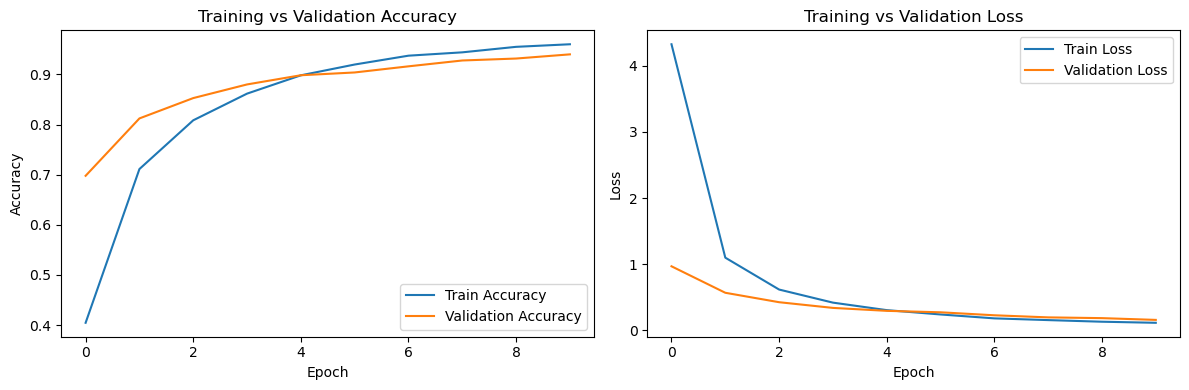

In [42]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [45]:
# Generator sırasını bozma
val_gen.reset()

# Tahmin olasılıkları
y_pred_probs = model.predict(val_gen, verbose=1)

# Olasılıktan sınıf index'i
y_pred = np.argmax(y_pred_probs, axis=1)

# GERÇEK label'lar (sparse olduğu için direkt alınır)
y_true = val_gen.classes


57/57 ━━━━━━━━━━━━━━━━━━━━ 230s 4s/step


##### Class names

In [47]:
class_names = list(val_gen.class_indices.keys())

#### Confusion Matrix

In [49]:
cm = confusion_matrix(y_true, y_pred)


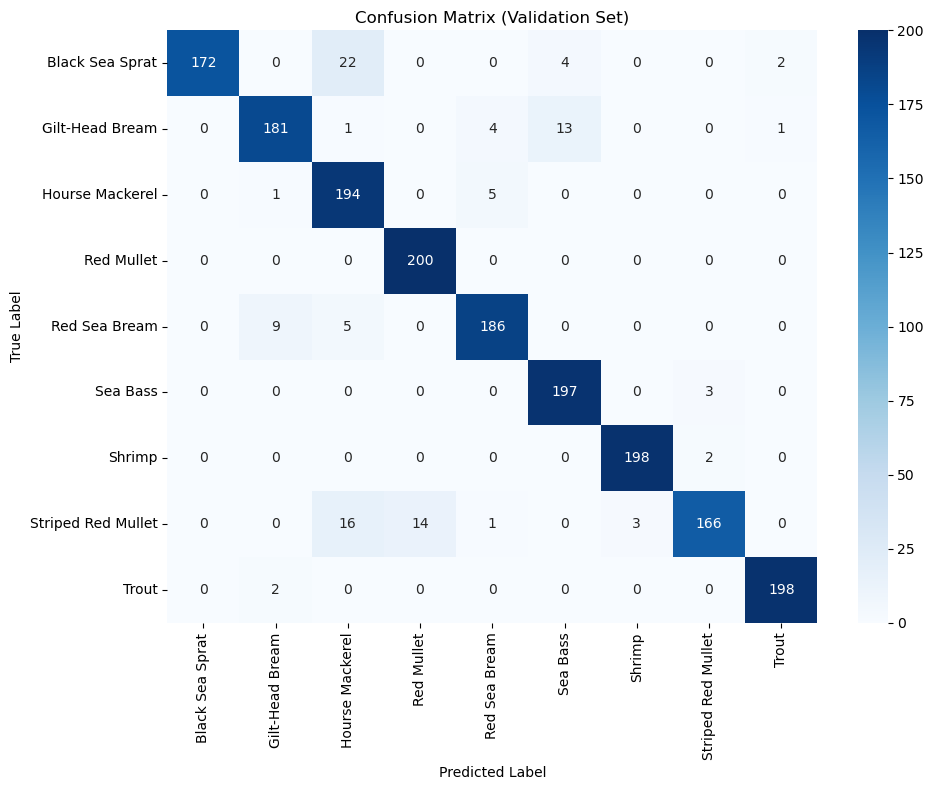

In [50]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Validation Set)")
plt.tight_layout()
plt.show()


##### Classification Report

In [51]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

                    precision    recall  f1-score   support

   Black Sea Sprat       1.00      0.86      0.92       200
   Gilt-Head Bream       0.94      0.91      0.92       200
   Hourse Mackerel       0.82      0.97      0.89       200
        Red Mullet       0.93      1.00      0.97       200
     Red Sea Bream       0.95      0.93      0.94       200
          Sea Bass       0.92      0.98      0.95       200
            Shrimp       0.99      0.99      0.99       200
Striped Red Mullet       0.97      0.83      0.89       200
             Trout       0.99      0.99      0.99       200

          accuracy                           0.94      1800
         macro avg       0.94      0.94      0.94      1800
      weighted avg       0.94      0.94      0.94      1800



##### Misclassified labels

In [53]:
import pandas as pd

In [54]:
pairs = []

for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            pairs.append({
                "Gerçek Sınıf": class_names[i],
                "Tahmin Edilen": class_names[j],
                "Hata Sayısı": cm[i, j]
            })

df_errors = pd.DataFrame(pairs)
df_errors = df_errors.sort_values(by="Hata Sayısı", ascending=False)

df_errors.head(10)

,Gerçek Sınıf,Tahmin Edilen,Hata Sayısı
0,Black Sea Sprat,Hourse Mackerel,22
13,Striped Red Mullet,Hourse Mackerel,16
14,Striped Red Mullet,Red Mullet,14
5,Gilt-Head Bream,Sea Bass,13
9,Red Sea Bream,Gilt-Head Bream,9
8,Hourse Mackerel,Red Sea Bream,5
10,Red Sea Bream,Hourse Mackerel,5
1,Black Sea Sprat,Sea Bass,4
4,Gilt-Head Bream,Red Sea Bream,4
11,Sea Bass,Striped Red Mullet,3


Bu calismada hem baseline cnn modelimiz ile hem de transfer learning metodu kullanarak 9 ayri balik sinifina ait tahmin modeli gelistirilmis olup ozellikle TL modeli ile ciddi bir basari orani yakalanmistir. Zaman ve performans kisitlamalarina takildigimiz icin 10 epochstan sonrasina gidilememistir, aslinda modelin hala ogrenmeye devam ettigini ve cok daha iyi performans ile sonuc vermeye devam edecegini basari oranlarindan yakalamis bulunmaktayiz.

Iki ayri modeli de simdi streamlit uygulamasi ile Hugging Face uygulamasina kaydederek tahmin modelimizi Hugging facede dunyaya acmis olacagiz.